In [185]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

In [186]:
# Parameters

#Experiment_Parameters
ts = 1e-05
t = 0.3

extra_hyst = 1005
tr = 0.001
w = [1e-05, 1.6e-05, 2.5e-05, 4e-05, 6.3e-05, 0.0001, 0.000158, 0.000251, 0.000398, 0.000631, 0.001, 0.001585, 0.002512]
high = -4
low = [1.2, 1.3, 1.4]

offset = 0
sd = 0.6
times = 3

#Physical_Parameters
tf = 2.55e-07
Af = 1e-07
del_F = 100000.0

#------ Model Parameters ------ #
rho = 370
alpha = -53644796.01936324
beta  = 1031363375.8835006

In [187]:
write_file_base = 'data/SampleD/Combined/'
low = [1.0, 1.1, 1.2, 1.3, 1.4] # for 09/05/25

In [188]:
# Theoretical plot functions
def F(x,y,alpha=1,beta=1): # potential function
    return beta*x**4 + alpha*x**2 - x*y

def der_F(x,y,alpha=1,beta=1): # derivative of the potential function wrt to x
    return 4*beta*x**3 + 2*alpha*x - y

def der2_F(x,alpha=1,beta=1): #Second derivative of the potential function wrt to x
    return 2*alpha + 12*beta*x**2

def findPAPC(e_bias,alpha,beta): # finding the inversion points
    xminL = sc.optimize.fsolve(der_F,-1,args=(e_bias,alpha,beta))
    xmax = sc.optimize.fsolve(der_F,0,args=(e_bias,alpha,beta))
    xminR = sc.optimize.fsolve(der_F,2,args=(e_bias,alpha,beta))
    return np.array([xminL, xmax, xminR])


def bistable_system(vals,hlev=1,llev=-1,hstate=1,lstate=-1): #this is a schmitt trigger
    state = lstate
    out_arr = np.zeros_like(vals)
    for i,val in enumerate(vals):
        if state == hstate:
            if val<llev:
                state = lstate
        else:
            if val>hlev:
                state = hstate
        out_arr[i] = state
    return out_arr

def kramerstime_calc(V,P_kramers,high,w,dt,P_thresh=0,switch_counts=[]): # Function for extracting kramers time
    # Kramers Time Calculation Logic
    mode_counter = bistable_system(V,hlev=-high*0.9,llev=high*0.9) # returns a clean signal without noise
    mode_count = np.sum(mode_counter)
    v_tracker = np.zeros_like(V,dtype=bool)
    if np.abs(mode_count)/len(mode_counter) <0.5:
        v_tracker[:-1] = np.logical_xor(V[1:]>0,V[:-1]>0)
    else:
        v_tracker[:-1] = np.logical_and(np.logical_not(np.sign(mode_count)*V[1:]>0),np.sign(mode_count)*V[:-1]>0)
    cycles = sum(v_tracker) #total number of cycles
    p_tracker = np.zeros_like(P_kramers,dtype=bool)
    p_tracker[:-1] = np.logical_xor((P_kramers[1:]-P_thresh)>0,(P_kramers[:-1]-P_thresh)>0) #any edge index
    vals =  [int(i) for i in np.where(v_tracker)[0]] + [None] # All the places where voltage switches

    for cycler in range(cycles):
        tmp = np.where(p_tracker[vals[cycler]:vals[cycler+1]])[0] # Selection of when it switches
        if len(tmp) != 0:
            kt_temp = tmp[0]*dt 
            if kt_temp < w*0.9 and kt_temp>0:
                switch_counts.append(kt_temp)
    return switch_counts

# Functions for fitting
def exponential(x, b):
    return 1- np.exp(-x/b)

def calculate_kramer_curve(sigma, bias, tf, Af, del_F):# Theory Calculation
    R_F = rho*tf/Af # Resistance of the sample
    Dext = sigma**2/(2*R_F*del_F*tf*Af)
    val = findPAPC(bias/tf,alpha,beta)
    P_A = val[0]
    P_C = val[1]
    tau_k = 2*np.pi*rho/(np.sqrt(np.abs(der2_F(P_A,alpha,beta)*der2_F(P_C,alpha,beta))))*np.exp((F(P_C,bias/tf,alpha,beta)-F(P_A,bias/tf,alpha,beta))/Dext)
    return tau_k

# sd correction
def sd_correction(Vdrive, V0):
    return np.std(Vdrive - V0)
    
def find_bitstream(t, V, P, th):
    r_edge = 0
    f_edge = 0
    sw_flag = 0
    trn = []
    t_r = []
    t_f = []
    for i in range(1,len(t)):
        # find the rising edge
        if (((V[i] - V[i-1]) > 0.5) and (r_edge == 0)): # 1V is the threshold
            r_edge = 1
            f_edge = 0
            t_r.append(t[i])
        # find the rising edge
        if (((V[i-1] - V[i]) > 0.5) and (f_edge  == 0)): # 1V is the threshold
            f_edge = 1
            r_edge = 0
            t_f.append(t[i])
            if(sw_flag == 0):
                trn.append(0)
                sw_flag = 0
            else:
                trn.append(1)
                sw_flag = 0
        
        # check if P is gone above the threshold in that period
        if((r_edge == 1) and (sw_flag == 0)):
            if(P[i] > th):
                sw_flag = 1
                # print("bit1")
    return trn


In [189]:
sd_cr = []
data = {}
for ap in low:
    trng_data = {}
    for wd in w:
        trn = []
        for itr in range(times):
            if (itr == 0):
                file_path = write_file_base + f"pulse_{ap}/"+ f"data_width_no_noise_{wd}_itr{itr}.txt"
                with open(file_path, 'r',encoding='latin-1') as file:
                    lines = file.readlines()

                t = []
                Vd = []
                P = []

                for line in lines[2:]:
                    values = line.strip().split('\t')
                    t.append(float(values[1]))
                    Vd.append(float(values[2]))
                    P.append(float(values[3]))

                dt = (t[2]-t[1])*1e-3
                # Extracting the portions of the Experiment
                t_trng_nn= np.array(t[extra_hyst:-extra_hyst])*1e-3
                Vd_trng_nn = np.array(Vd[extra_hyst:-extra_hyst])
                P_trng_nn = np.array(P[extra_hyst:-extra_hyst])

            file_path = write_file_base + f"pulse_{ap}/"+ f"data_width_{wd}_itr{itr}.txt"
            with open(file_path, 'r',encoding='latin-1') as file:
                lines = file.readlines()

            t = []
            Vd = []
            P = []

            for line in lines[2:]:
                values = line.strip().split('\t')
                t.append(float(values[1]))
                Vd.append(float(values[2]))
                P.append(float(values[3]))

            dt = (t[2]-t[1])*1e-3
            # Extracting the portions of the Experiment
            t_trng = np.array(t[extra_hyst:-extra_hyst])*1e-3
            Vd_trng = np.array(Vd[extra_hyst:-extra_hyst])
            P_trng = np.array(P[extra_hyst:-extra_hyst])
            trn += find_bitstream(t_trng, Vd_trng_nn, P_trng, th = 0)
            
            sd_cr.append(sd_correction(Vd_trng_nn, Vd_trng))
        trng_data[wd] = trn
    data[ap] = trng_data

[0.5187012774521124, 0.5151128996458574, 0.5177236654378322, 0.515184760845322, 0.5126560981711743, 0.517270872778877, 0.5113253189237711, 0.5170049690399833, 0.5143537188688079, 0.5648001575540097, 0.5649422634081824, 0.5691486128961766, 1.0623115784292583, 1.07165335782239, 1.0658276005881864, 1.416821636496886, 1.4130531409946077, 1.4123314589638702, 1.7065943871555695, 1.7088948397763581, 1.7106798216187955, 2.001312787699721, 2.006390809233176, 1.999785141935161, 2.253298668011714, 2.2578746785225845, 2.260551404996025, 2.443733166851368, 2.4448545590173145, 2.4508024144989484, 2.521119068281307, 2.5225824669401673, 2.529551355383553, 2.458859133835976, 2.4640318242782993, 2.469829002016508, 2.3001799066111026, 2.3002995824558528, 2.303944596890371, 0.5201747219462588, 0.5179926750832411, 0.5146405219024554, 0.5185127307887072, 0.5125175259839414, 0.5186514217126131, 0.515788440790551, 0.5163924443106569, 0.5155080120466783, 0.5556647045469882, 0.5583997148234248, 0.55335770226614

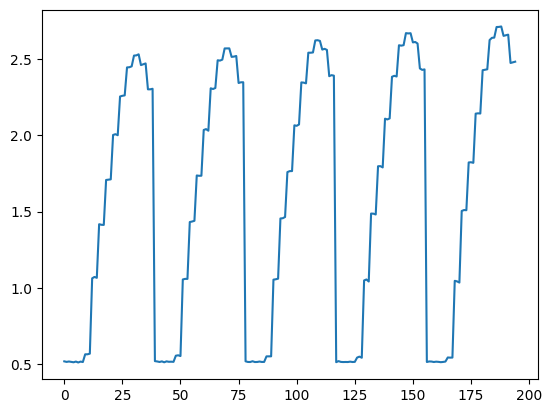

In [190]:
plt.plot(sd_cr)
print(sd_cr)

In [222]:
sd_cr_ext = 0.5

Text(0.5, 1.0, 'combined')

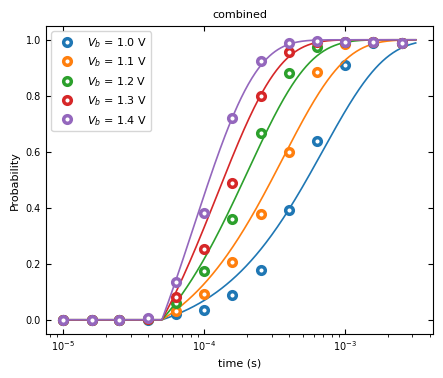

In [238]:
t_comp = 5e-5
pulse_width_th = np.logspace(-5, -2.5, 500)
pulse_width_th_comp = np.array([np.clip(tp-t_comp, 0, 100) for tp in pulse_width_th])

offset = 0.3
# Style parameters
clr = ["#1f77b4",  # blue
       "#ff7f0e",  # orange
       "#2ca02c",  # green
       "#d62728",  # red
       "#9467bd",  # purple
       "#8c564b",  # brown
       "#e377c2",  # pink
       "#7f7f7f",  # gray
       "#bcbd22",  # olive
       "#17becf"]  # cyan
lwth = 1.2         # line width
msize = 5.5        # marker size
fsize = 8           # font size
m = "o"
mwth = 2.5

# Figure size (6 in wide, 2 in tall)
fig = plt.figure(figsize=(5, 4))
i = 0
for v, pdata in data.items():
    Prob = []
    for wd, bs in pdata.items():
        Prob.append(sum(bs)/len(bs))
    plt.semilogx(pulse_width_th, exponential(pulse_width_th_comp, calculate_kramer_curve(sd_cr_ext, float(v), tf, Af, del_F)), "-", c=clr[i], linewidth = lwth, label="")
    plt.semilogx(w, Prob, m, c=clr[i], ms=msize, mew = mwth, markerfacecolor='white', label=f"$V_b$ = {v} V")
    i += 1
    
plt.tick_params(axis="both", labelsize=fsize-1)
plt.tick_params(axis="both", direction="in", top=True, right=True, labelsize=fsize-1)
plt.legend(fontsize=fsize)
plt.xlabel("time (s)", fontsize=fsize)
plt.ylabel("Probability", fontsize=fsize)
plt.title("combined", fontsize=fsize)

In [224]:
# file_path = write_file_base + f"pulse_{ap}/"+ f"data_width_no_noise_{w[2]}_itr{0}.txt"
# with open(file_path, 'r',encoding='latin-1') as file:
#     lines = file.readlines()

# t = []
# Vd = []
# P = []

# for line in lines[2:]:
#     values = line.strip().split('\t')
#     t.append(float(values[1]))
#     Vd.append(float(values[2]))
#     P.append(float(values[3]))

# dt = (t[2]-t[1])*1e-3
# # Extracting the portions of the Experiment
# Vd_trng_nn = np.array(Vd[extra_hyst:-extra_hyst])


# file_path = write_file_base + f"pulse_{ap}/"+ f"data_width_{w[2]}_itr{1}.txt"
# with open(file_path, 'r',encoding='latin-1') as file:
#     lines = file.readlines()

# t = []
# Vd = []
# P = []

# for line in lines[2:]:
#     values = line.strip().split('\t')
#     t.append(float(values[1]))
#     Vd.append(float(values[2]))
#     P.append(float(values[3]))

# dt = (t[2]-t[1])*1e-3
# # Extracting the portions of the Experiment
# t_trng= np.array(t[extra_hyst:-extra_hyst])*1e-3
# Vd_trng = np.array(Vd[extra_hyst:-extra_hyst])
# P_trng = np.array(P[extra_hyst:-extra_hyst])

In [225]:
# plt.subplot(2,1,1); plt.plot(t_trng, Vd_trng - Vd_trng_nn); plt.xlim([0.01,0.05])

In [226]:
# tr,tf,trn = find_bitstream(t_trng, Vd_trng_nn, P_trng, th = 0)
# trn

In [227]:
# plt.subplot(2,1,1); plt.plot(t_trng[0:2000], Vd_trng_nn[0:2000]); plt.scatter(tr[0:18], np.array(tr[0:18])*0);  plt.scatter(tf[0:18], np.array(tf[0:18])*0);
# plt.subplot(2,1,2); plt.plot(t_trng[0:2000], P_trng[0:2000])


In [228]:
# # hystersis overlap
# plt.plot(Vd[0:extra_hyst], P[0:extra_hyst])
# plt.plot(Vd[-extra_hyst:-1], P[-extra_hyst:-1])